Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/DataSets/student-por.csv')

Missing Values Analysis:Compute the absolute and percentage missing for every column.




In [2]:
missing = df.isnull().sum()
missing_df = pd.DataFrame({
 "Missing Count": missing,
 "Missing %": round(missing / len(df) * 100, 2)
})
missing_df.sort_values(by="Missing Count", ascending=False)


,Missing Count,Missing %
school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3,0,0.0


Missing Values Visualisation

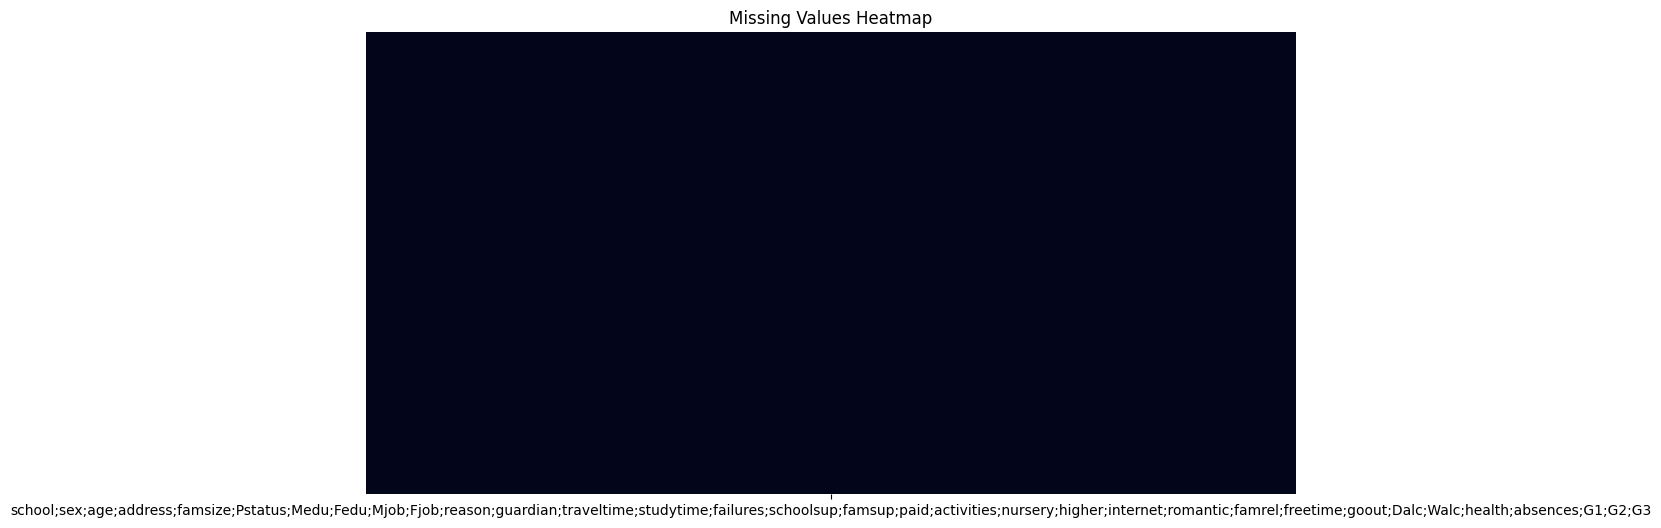

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)

plt.title("Missing Values Heatmap")
plt.show()

Handle Missing Values:Numerical Columns — Fill with Median


In [4]:
import numpy as np

numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("Numerical Features:")
print(list(numeric_cols))

print("\nCategorical Features:")
print(list(categorical_cols))

Numerical Features:
[]

Categorical Features:
['school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3']


In [5]:
for col in numeric_cols:
 df[col].fillna(df[col].median(), inplace=True)

Handle Missing Values:Categorical Columns — Fill with Mode

In [6]:
for col in categorical_cols:
 df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_2801/1086946666.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


Duplicate Records

In [ ]:
print('Duplicates found:', df.duplicated().sum())
df.drop_duplicates(inplace=True)

Outlier Detection

In [8]:
for col in numeric_cols:
 plt.figure(figsize=(8, 4))
 sns.boxplot(x=df[col])
 plt.title(col)
 plt.show()


 Outlier Treatment (IQR Method)


In [10]:
for col in numeric_cols:
 Q1 = df[col].quantile(0.25)
 Q3 = df[col].quantile(0.75)
 IQR = Q3 - Q1
 lower = Q1 - 1.5 * IQR
 upper = Q3 + 1.5 * IQR
 df = df[(df[col] >= lower) & (df[col] <= upper)]

Verify Cleaning

In [11]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                               Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                               --------------  ----- 
 0   school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3  649 non-null    object
dtypes: object(1)
memory usage: 5.2+ KB


,0
school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3,0


Save Cleaned Dataset

In [12]:
df.to_csv("cleaned_dataset.csv", index=False)